# Week 11 Jupyter Notebook — Clustering: Part 2
## DBSCAN, HAC, Linkage Methods, and Dendrograms

**Integrated Capstone Project:** Wisconsin and Coimbra Breast Cancer Datasets  
**Week topic:** DBSCAN, hierarchical agglomerative clustering, linkage methods, and dendrograms

### Notebook purpose

For Week 11, I am applying clustering methods to both of my capstone datasets:

1. **Breast Cancer Wisconsin Diagnostic dataset** — tumor image-based measurements.
2. **Breast Cancer Coimbra dataset** — clinical and blood-based biomarkers.

This week is unsupervised learning. The clustering models do **not** use the diagnosis label when forming groups. I only compare clusters to the known label afterward to help interpret whether natural patterns in the data resemble the known cancer outcome.

For this notebook, I focus on:

- Density-based spatial clustering of applications with noise (**DBSCAN**)
- DBSCAN `eps` and `min_samples`
- Noise points
- Hierarchical agglomerative clustering (**HAC**)
- Linkage methods: ward, complete, average, and single
- Dendrograms
- Wisconsin vs. Coimbra interpretation

## 1. Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

from scipy.cluster.hierarchy import linkage, dendrogram

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)


## 2. Helper functions

These helper functions keep the Wisconsin and Coimbra analyses consistent.

In [2]:
def scale_features(X):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return pd.DataFrame(X_scaled, columns=X.columns, index=X.index), scaler


def make_pca_df(X_scaled):
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X_scaled)
    return pd.DataFrame({"PC1": coords[:, 0], "PC2": coords[:, 1]}, index=X_scaled.index), pca


def safe_silhouette(X_scaled, labels, remove_noise=False):
    labels = np.asarray(labels)
    if remove_noise:
        mask = labels != -1
        if mask.sum() < 3:
            return np.nan
        X_used = X_scaled.loc[mask]
        labels_used = labels[mask]
    else:
        X_used = X_scaled
        labels_used = labels
    if len(np.unique(labels_used)) < 2 or len(np.unique(labels_used)) >= len(labels_used):
        return np.nan
    return silhouette_score(X_used, labels_used)


def cluster_summary(dataset, method, labels, y_true, X_scaled):
    labels = np.asarray(labels)
    clusters_no_noise = [x for x in np.unique(labels) if x != -1]
    n_noise = int((labels == -1).sum())
    return {
        "dataset": dataset,
        "method": method,
        "clusters_excluding_noise": len(clusters_no_noise),
        "noise_points": n_noise,
        "noise_rate": n_noise / len(labels),
        "silhouette_all_points": safe_silhouette(X_scaled, labels, remove_noise=False),
        "silhouette_without_noise": safe_silhouette(X_scaled, labels, remove_noise=True),
        "ARI_vs_known_label": adjusted_rand_score(y_true, labels),
        "NMI_vs_known_label": normalized_mutual_info_score(y_true, labels)
    }


def plot_clusters(pca_df, labels, title):
    plot_df = pca_df.copy()
    plot_df["cluster"] = labels
    plt.figure(figsize=(8, 6))
    for cluster in sorted(plot_df["cluster"].unique()):
        group = plot_df[plot_df["cluster"] == cluster]
        plt.scatter(group["PC1"], group["PC2"], alpha=0.75, label=f"Cluster {cluster}")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_known_labels(pca_df, y_true, label_map, title):
    plot_df = pca_df.copy()
    plot_df["known_label"] = y_true
    plt.figure(figsize=(8, 6))
    for value, label in label_map.items():
        group = plot_df[plot_df["known_label"] == value]
        plt.scatter(group["PC1"], group["PC2"], alpha=0.75, label=label)
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def dbscan_grid_search(X_scaled, y_true, dataset_name, eps_values, min_samples_values):
    rows = []
    for eps in eps_values:
        for min_samples in min_samples_values:
            model = DBSCAN(eps=eps, min_samples=min_samples)
            labels = model.fit_predict(X_scaled)
            row = cluster_summary(dataset_name, f"DBSCAN eps={eps}, min_samples={min_samples}", labels, y_true, X_scaled)
            row["eps"] = eps
            row["min_samples"] = min_samples
            rows.append(row)
    return pd.DataFrame(rows)


def choose_dbscan(search_df):
    valid = search_df[(search_df["clusters_excluding_noise"] >= 2) & (search_df["noise_rate"] < 0.50)].copy()
    if len(valid) > 0:
        return valid.sort_values(["silhouette_without_noise", "noise_rate"], ascending=[False, True]).iloc[0]
    return search_df.sort_values(["silhouette_without_noise", "noise_rate"], ascending=[False, True]).iloc[0]


def hac_linkage_comparison(X_scaled, y_true, dataset_name):
    rows = []
    labels_by_linkage = {}
    for method in ["ward", "complete", "average", "single"]:
        model = AgglomerativeClustering(n_clusters=2, linkage=method)
        labels = model.fit_predict(X_scaled)
        row = cluster_summary(dataset_name, f"HAC linkage={method}", labels, y_true, X_scaled)
        row["linkage"] = method
        rows.append(row)
        labels_by_linkage[method] = labels
    return pd.DataFrame(rows), labels_by_linkage


# Part A — Wisconsin Dataset

## 3. Load and prepare Wisconsin dataset

The sklearn version uses `0 = malignant` and `1 = benign`, so I recode it as `1 = malignant` and `0 = benign`. The clustering models do not use this label during training.

In [3]:
cancer = load_breast_cancer()
wisconsin_df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
wisconsin_df.columns = wisconsin_df.columns.str.replace(" ", "_")
wisconsin_df["diagnosis_malignant"] = (cancer.target == 0).astype(int)
wisconsin_df["diagnosis_label"] = np.where(wisconsin_df["diagnosis_malignant"] == 1, "Malignant", "Benign")

print("Wisconsin shape:", wisconsin_df.shape)
print(wisconsin_df["diagnosis_label"].value_counts())
wisconsin_df.head()


Wisconsin shape: (569, 32)
diagnosis_label
Benign       357
Malignant    212
Name: count, dtype: int64


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,diagnosis_malignant,diagnosis_label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1,Malignant


## 4. Wisconsin features, scaling, and PCA view

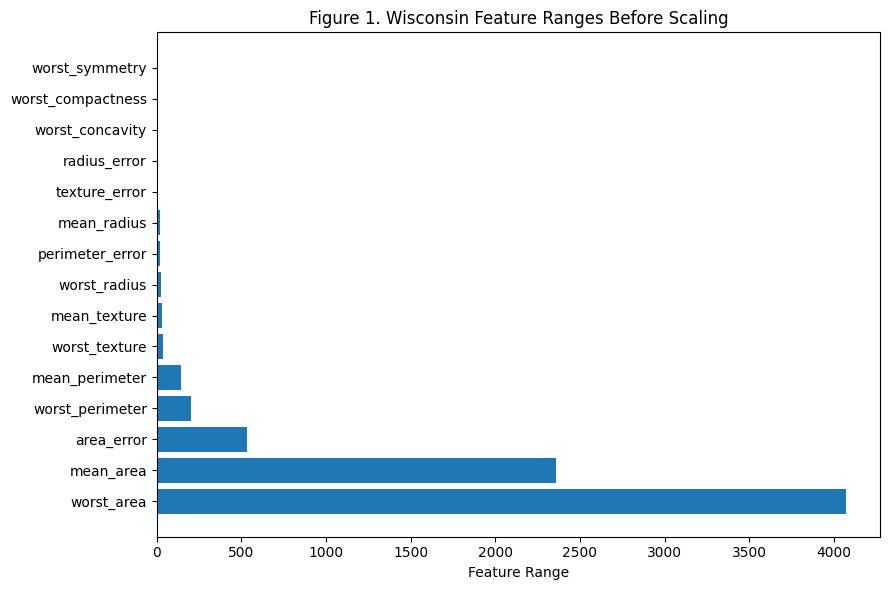

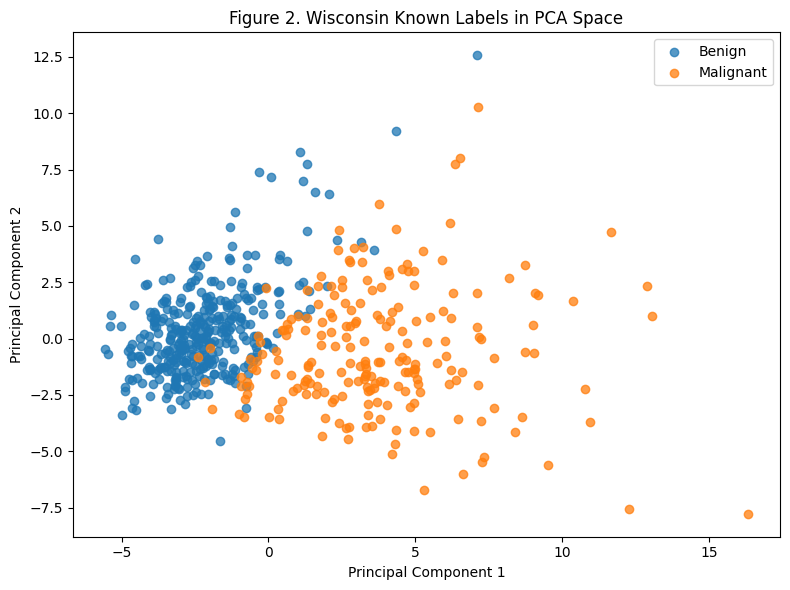

In [4]:
wisconsin_features = [c for c in wisconsin_df.columns if c not in ["diagnosis_malignant", "diagnosis_label"]]
X_w = wisconsin_df[wisconsin_features]
y_w = wisconsin_df["diagnosis_malignant"]

w_scale = X_w.agg(["min", "max", "mean", "std"]).T
w_scale["range"] = w_scale["max"] - w_scale["min"]
w_scale = w_scale.sort_values("range", ascending=False).head(15)

plt.figure(figsize=(9, 6))
plt.barh(w_scale.index, w_scale["range"])
plt.xlabel("Feature Range")
plt.title("Figure 1. Wisconsin Feature Ranges Before Scaling")
plt.tight_layout()
plt.show()

X_w_scaled, w_scaler = scale_features(X_w)
w_pca_df, w_pca = make_pca_df(X_w_scaled)

plot_known_labels(w_pca_df, y_w, {0: "Benign", 1: "Malignant"}, "Figure 2. Wisconsin Known Labels in PCA Space")


## 5. Wisconsin DBSCAN k-distance plot

I use the 5th nearest neighbor distance as a guide for choosing `eps`. A sharp bend in this curve can suggest a reasonable starting `eps`.

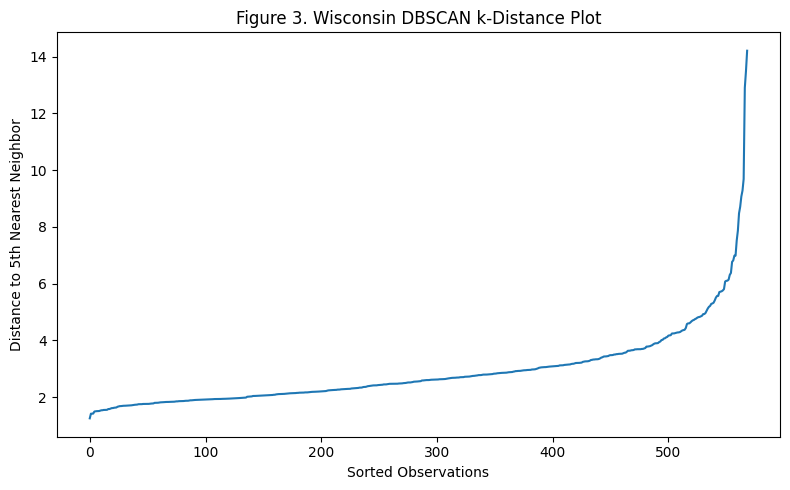

,0
count,569.000000
mean,2.904996
std,1.441666
min,1.248460
25%,2.036675
50%,2.552499
75%,3.239679
max,14.212836


In [5]:
min_samples_start = 5
nbrs = NearestNeighbors(n_neighbors=min_samples_start).fit(X_w_scaled)
distances, indices = nbrs.kneighbors(X_w_scaled)
k_distances = np.sort(distances[:, min_samples_start - 1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.xlabel("Sorted Observations")
plt.ylabel("Distance to 5th Nearest Neighbor")
plt.title("Figure 3. Wisconsin DBSCAN k-Distance Plot")
plt.tight_layout()
plt.show()

pd.Series(k_distances).describe()


## 6. Wisconsin DBSCAN parameter search

In [6]:
w_search = dbscan_grid_search(
    X_scaled=X_w_scaled,
    y_true=y_w,
    dataset_name="Wisconsin",
    eps_values=[1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5],
    min_samples_values=[3, 5, 8, 10]
)

w_search.sort_values(["clusters_excluding_noise", "silhouette_without_noise", "noise_rate"], ascending=[False, False, True]).head(15)


,dataset,method,clusters_excluding_noise,noise_points,noise_rate,silhouette_all_points,silhouette_without_noise,ARI_vs_known_label,NMI_vs_known_label,eps,min_samples
4,Wisconsin,"DBSCAN eps=2.0, min_samples=3",7,336,0.590510,-0.203959,0.081566,0.142157,0.229118,2.0,3
0,Wisconsin,"DBSCAN eps=1.5, min_samples=3",6,513,0.901582,-0.338198,0.159162,-0.042527,0.093148,1.5,3
8,Wisconsin,"DBSCAN eps=2.5, min_samples=3",5,200,0.351494,-0.075507,0.076333,0.214740,0.153876,2.5,3
5,Wisconsin,"DBSCAN eps=2.0, min_samples=5",4,371,0.652021,-0.198514,0.097753,0.096351,0.203526,2.0,5
12,Wisconsin,"DBSCAN eps=3.0, min_samples=3",2,111,0.195079,0.256691,0.435961,0.120337,0.074060,3.0,3
11,Wisconsin,"DBSCAN eps=2.5, min_samples=10",2,264,0.463972,0.030703,0.294094,0.264893,0.232743,2.5,10
10,Wisconsin,"DBSCAN eps=2.5, min_samples=8",2,252,0.442882,0.017805,0.168579,0.210034,0.160210,2.5,8
9,Wisconsin,"DBSCAN eps=2.5, min_samples=5",2,224,0.393673,-0.016791,0.129459,0.207788,0.145263,2.5,5
24,Wisconsin,"DBSCAN eps=4.5, min_samples=3",1,28,0.049209,0.461266,NaN,0.024331,0.013636,4.5,3
25,Wisconsin,"DBSCAN eps=4.5, min_samples=5",1,32,0.056239,0.449810,NaN,0.025968,0.013646,4.5,5


## 7. Wisconsin final DBSCAN model

I choose a DBSCAN model that finds at least two clusters and avoids marking too much of the dataset as noise.

Selected Wisconsin eps: 3.0
Selected Wisconsin min_samples: 3


,dataset,method,clusters_excluding_noise,noise_points,noise_rate,silhouette_all_points,silhouette_without_noise,ARI_vs_known_label,NMI_vs_known_label
0,Wisconsin,"DBSCAN eps=3.0, min_samples=3",2,111,0.195079,0.256691,0.435961,0.120337,0.07406


diagnosis_label,Benign,Malignant,All
DBSCAN_cluster,,,
-1,40,71,111
0,317,137,454
1,0,4,4
All,357,212,569


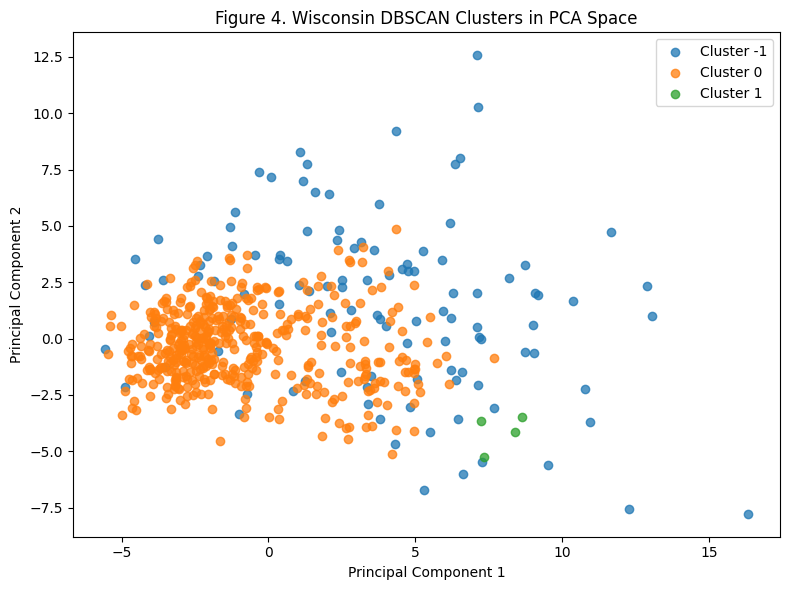

In [7]:
w_best_row = choose_dbscan(w_search)
w_best_eps = float(w_best_row["eps"])
w_best_min_samples = int(w_best_row["min_samples"])

w_dbscan = DBSCAN(eps=w_best_eps, min_samples=w_best_min_samples)
w_dbscan_labels = w_dbscan.fit_predict(X_w_scaled)
w_dbscan_summary = cluster_summary("Wisconsin", f"DBSCAN eps={w_best_eps}, min_samples={w_best_min_samples}", w_dbscan_labels, y_w, X_w_scaled)

print("Selected Wisconsin eps:", w_best_eps)
print("Selected Wisconsin min_samples:", w_best_min_samples)
display(pd.DataFrame([w_dbscan_summary]))

display(pd.crosstab(pd.Series(w_dbscan_labels, name="DBSCAN_cluster"), wisconsin_df["diagnosis_label"], margins=True))
plot_clusters(w_pca_df, w_dbscan_labels, "Figure 4. Wisconsin DBSCAN Clusters in PCA Space")


### Wisconsin DBSCAN interpretation

DBSCAN is helpful because it can identify unusual observations as noise. In healthcare data, this could represent cases that do not fit neatly into the main groups. For Wisconsin, I expect DBSCAN to show more useful structure than Coimbra because tumor morphology features are directly related to diagnosis.

## 8. Wisconsin HAC linkage comparison

I compare Ward, complete, average, and single linkage using two clusters.

In [8]:
w_hac_df, w_hac_labels = hac_linkage_comparison(X_w_scaled, y_w, "Wisconsin")
w_hac_df.sort_values("silhouette_all_points", ascending=False)


,dataset,method,clusters_excluding_noise,noise_points,noise_rate,silhouette_all_points,silhouette_without_noise,ARI_vs_known_label,NMI_vs_known_label,linkage
1,Wisconsin,HAC linkage=complete,2,0,0.0,0.660667,0.660667,0.004828,0.010182,complete
3,Wisconsin,HAC linkage=single,2,0,0.0,0.660667,0.660667,0.004828,0.010182,single
2,Wisconsin,HAC linkage=average,2,0,0.0,0.633978,0.633978,0.007276,0.015086,average
0,Wisconsin,HAC linkage=ward,2,0,0.0,0.339385,0.339385,0.575041,0.456915,ward


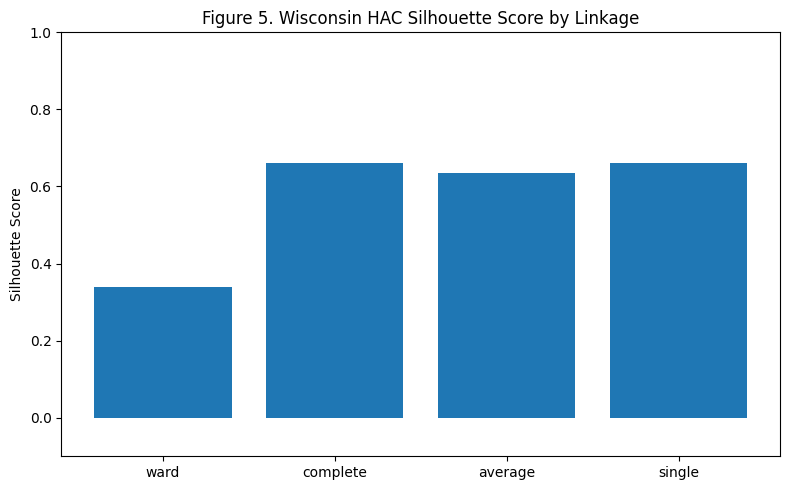

In [9]:
plt.figure(figsize=(8, 5))
plt.bar(w_hac_df["linkage"], w_hac_df["silhouette_all_points"])
plt.ylabel("Silhouette Score")
plt.title("Figure 5. Wisconsin HAC Silhouette Score by Linkage")
plt.ylim(-0.1, 1.0)
plt.tight_layout()
plt.show()


## 9. Wisconsin final HAC model

Best Wisconsin linkage: complete


,dataset,method,clusters_excluding_noise,noise_points,noise_rate,silhouette_all_points,silhouette_without_noise,ARI_vs_known_label,NMI_vs_known_label,linkage
1,Wisconsin,HAC linkage=complete,2,0,0.0,0.660667,0.660667,0.004828,0.010182,complete


diagnosis_label,Benign,Malignant,All
HAC_cluster,,,
0,357,210,567
1,0,2,2
All,357,212,569


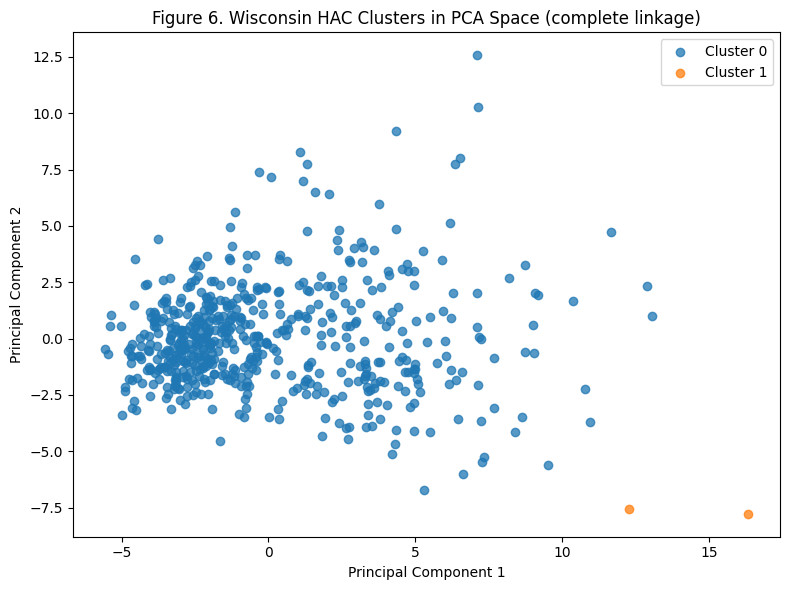

In [10]:
w_best_hac = w_hac_df.sort_values("silhouette_all_points", ascending=False).iloc[0]
w_best_linkage = w_best_hac["linkage"]
w_best_hac_labels = w_hac_labels[w_best_linkage]

print("Best Wisconsin linkage:", w_best_linkage)
display(pd.DataFrame([w_best_hac]))
display(pd.crosstab(pd.Series(w_best_hac_labels, name="HAC_cluster"), wisconsin_df["diagnosis_label"], margins=True))
plot_clusters(w_pca_df, w_best_hac_labels, f"Figure 6. Wisconsin HAC Clusters in PCA Space ({w_best_linkage} linkage)")


## 10. Wisconsin dendrograms

I use a random sample of 80 Wisconsin observations so the dendrograms stay readable.

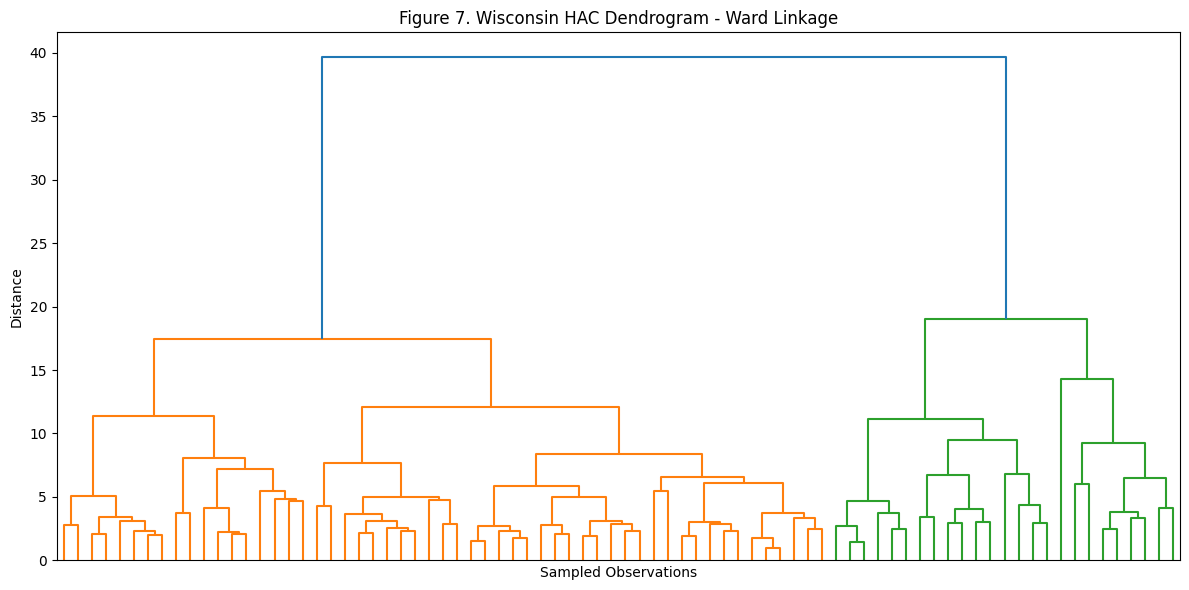

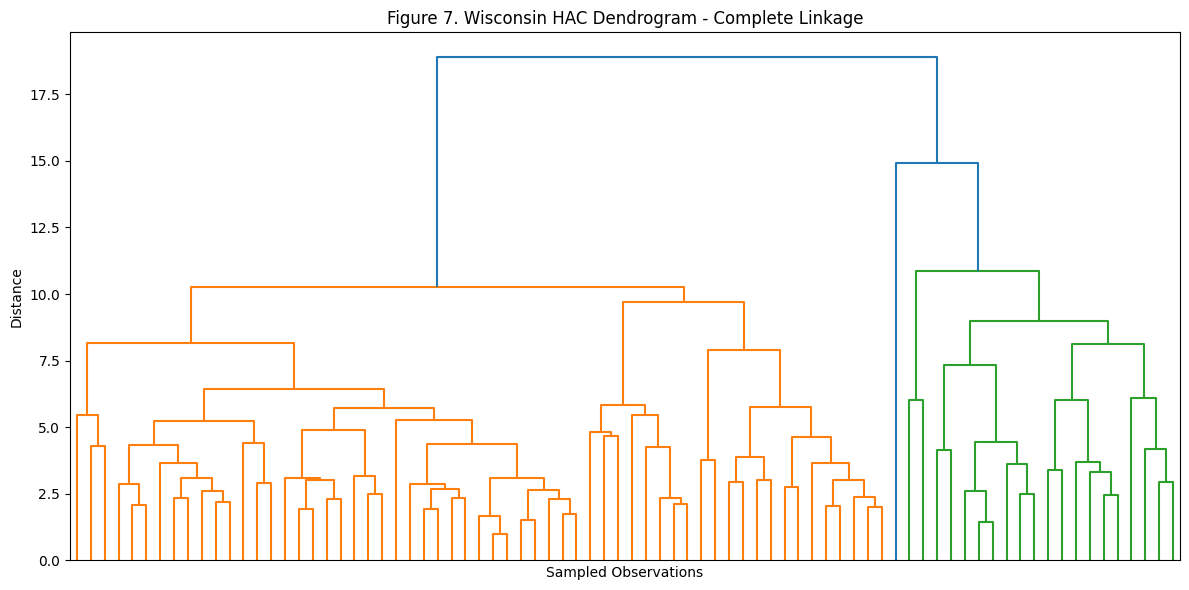

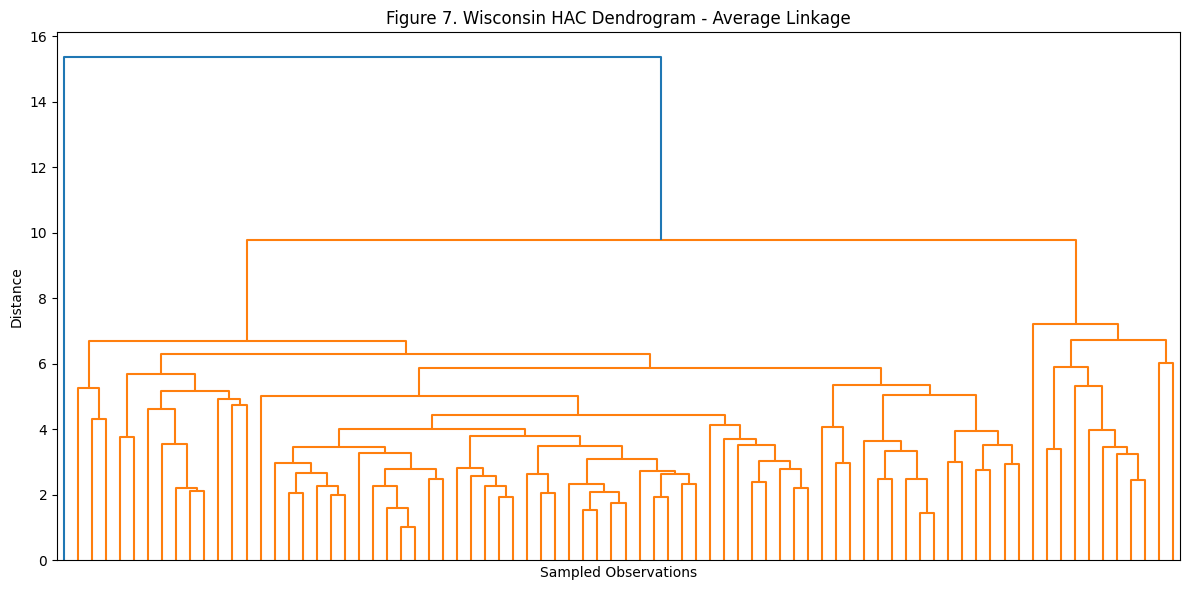

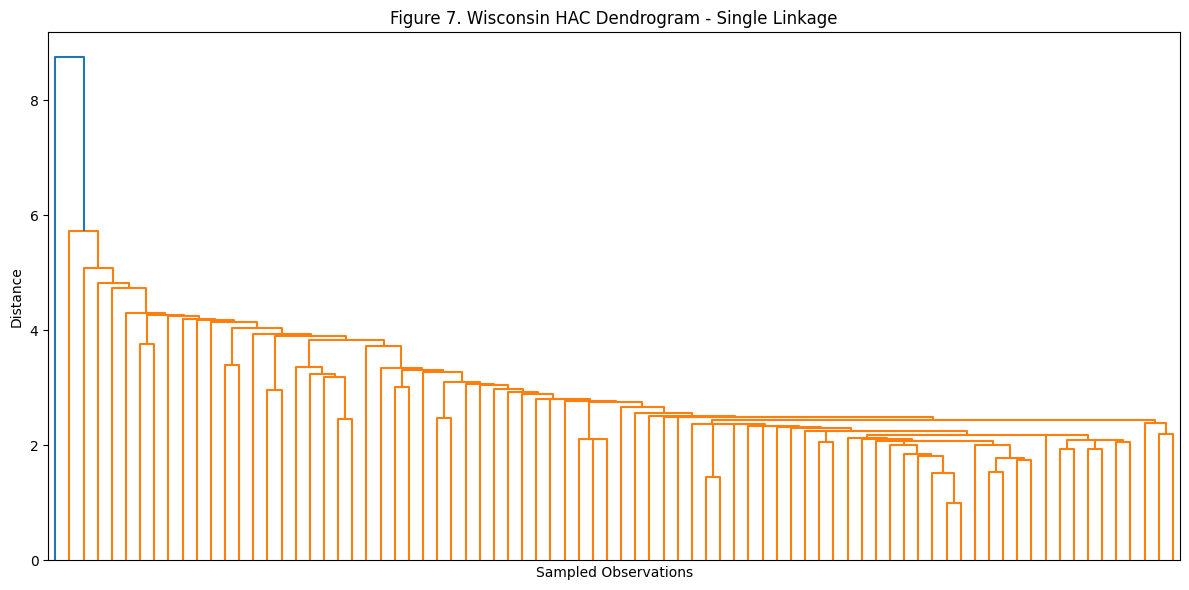

In [11]:
w_sample = X_w_scaled.sample(n=80, random_state=42)

for method in ["ward", "complete", "average", "single"]:
    linked = linkage(w_sample, method=method)
    plt.figure(figsize=(12, 6))
    dendrogram(linked, no_labels=True)
    plt.title(f"Figure 7. Wisconsin HAC Dendrogram - {method.capitalize()} Linkage")
    plt.xlabel("Sampled Observations")
    plt.ylabel("Distance")
    plt.tight_layout()
    plt.show()


### Wisconsin HAC interpretation

HAC shows cluster structure as a hierarchy. The linkage method matters because each method defines distance between clusters differently. Ward linkage often creates compact clusters, while single linkage can create chain-like clusters.

# Part B — Coimbra Dataset

## 11. Load and prepare Coimbra dataset

The Coimbra target is `Classification`, where `1 = healthy control` and `2 = breast cancer patient`. I recode it so `1 = patient` and `0 = healthy control`.

In [13]:
coimbra_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00451/dataR2.csv"
coimbra_df = pd.read_csv(coimbra_url)
coimbra_df.columns = (coimbra_df.columns.str.strip().str.replace(" ", "_").str.replace("-", "_").str.replace(".", "_", regex=False))
coimbra_df["breast_cancer_present"] = (coimbra_df["Classification"] == 2).astype(int)
coimbra_df["diagnosis_group"] = np.where(coimbra_df["breast_cancer_present"] == 1, "Patient", "Healthy Control")

print("Coimbra shape:", coimbra_df.shape)
print(coimbra_df["diagnosis_group"].value_counts())
print("Missing values:")
print(coimbra_df.isna().sum())
coimbra_df.head()


Coimbra shape: (116, 12)
diagnosis_group
Patient            64
Healthy Control    52
Name: count, dtype: int64
Missing values:
Age                      0
BMI                      0
Glucose                  0
Insulin                  0
HOMA                     0
Leptin                   0
Adiponectin              0
Resistin                 0
MCP_1                    0
Classification           0
breast_cancer_present    0
diagnosis_group          0
dtype: int64


,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP_1,Classification,breast_cancer_present,diagnosis_group
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114,1,0,Healthy Control
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786,1,0,Healthy Control
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697,1,0,Healthy Control
3,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220,1,0,Healthy Control
4,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920,1,0,Healthy Control


## 12. Coimbra features, scaling, and PCA view

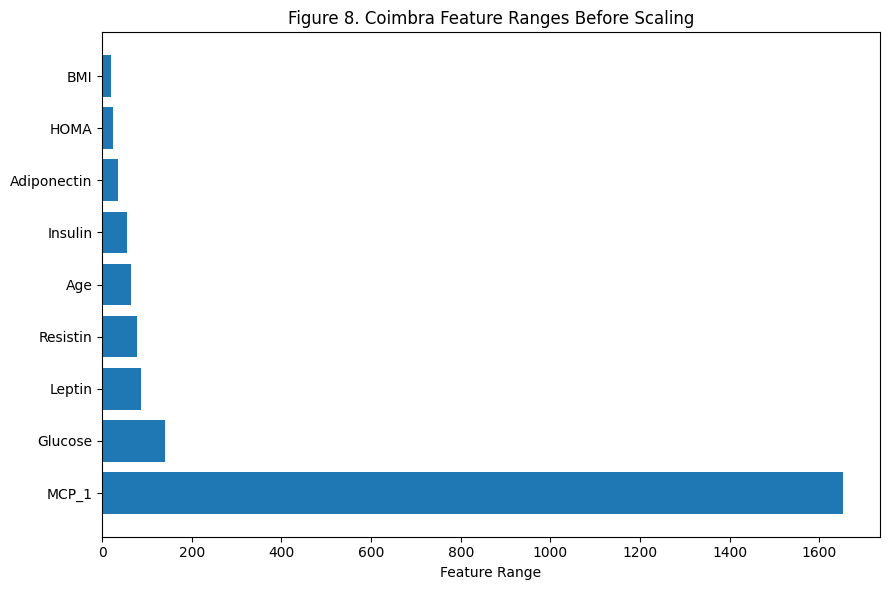

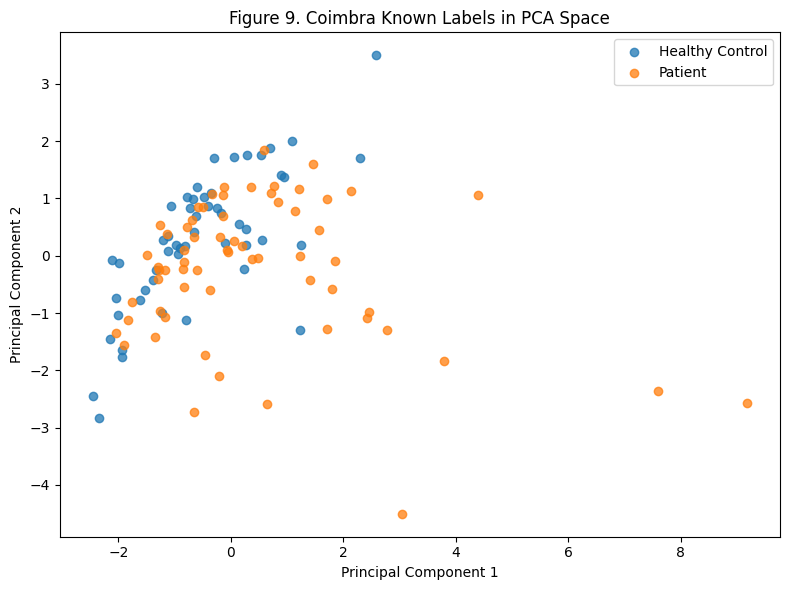

In [14]:
coimbra_features = [c for c in coimbra_df.columns if c not in ["Classification", "breast_cancer_present", "diagnosis_group"]]
X_c = coimbra_df[coimbra_features]
y_c = coimbra_df["breast_cancer_present"]

c_scale = X_c.agg(["min", "max", "mean", "std"]).T
c_scale["range"] = c_scale["max"] - c_scale["min"]
c_scale = c_scale.sort_values("range", ascending=False)

plt.figure(figsize=(9, 6))
plt.barh(c_scale.index, c_scale["range"])
plt.xlabel("Feature Range")
plt.title("Figure 8. Coimbra Feature Ranges Before Scaling")
plt.tight_layout()
plt.show()

X_c_scaled, c_scaler = scale_features(X_c)
c_pca_df, c_pca = make_pca_df(X_c_scaled)

plot_known_labels(c_pca_df, y_c, {0: "Healthy Control", 1: "Patient"}, "Figure 9. Coimbra Known Labels in PCA Space")


## 13. Coimbra DBSCAN k-distance plot

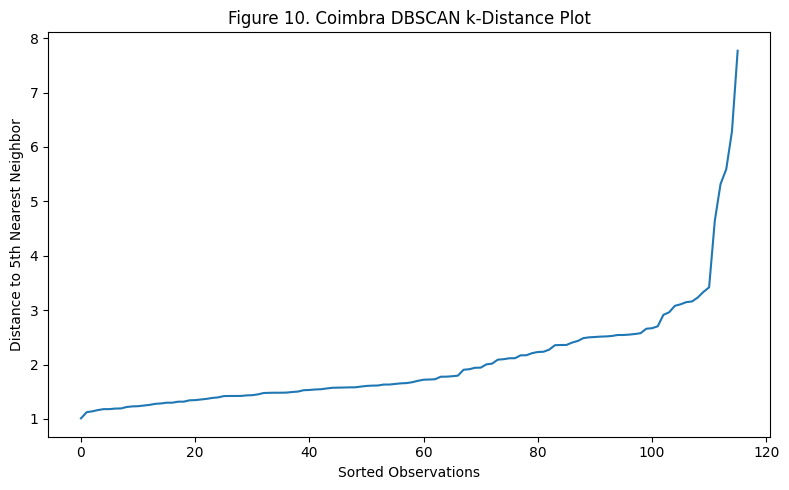

,0
count,116.000000
mean,2.041376
std,1.030259
min,1.010264
25%,1.429541
50%,1.666256
75%,2.410576
max,7.769947


In [15]:
nbrs = NearestNeighbors(n_neighbors=min_samples_start).fit(X_c_scaled)
distances, indices = nbrs.kneighbors(X_c_scaled)
k_distances_c = np.sort(distances[:, min_samples_start - 1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances_c)
plt.xlabel("Sorted Observations")
plt.ylabel("Distance to 5th Nearest Neighbor")
plt.title("Figure 10. Coimbra DBSCAN k-Distance Plot")
plt.tight_layout()
plt.show()

pd.Series(k_distances_c).describe()


## 14. Coimbra DBSCAN parameter search

In [16]:
c_search = dbscan_grid_search(
    X_scaled=X_c_scaled,
    y_true=y_c,
    dataset_name="Coimbra",
    eps_values=[0.8, 1.0, 1.2, 1.5, 1.8, 2.0, 2.5, 3.0],
    min_samples_values=[3, 4, 5, 8]
)

c_search.sort_values(["clusters_excluding_noise", "silhouette_without_noise", "noise_rate"], ascending=[False, False, True]).head(15)


,dataset,method,clusters_excluding_noise,noise_points,noise_rate,silhouette_all_points,silhouette_without_noise,ARI_vs_known_label,NMI_vs_known_label,eps,min_samples
4,Coimbra,"DBSCAN eps=1.0, min_samples=3",3,103,0.887931,-0.201058,0.427230,0.008383,0.055661,1.0,3
9,Coimbra,"DBSCAN eps=1.2, min_samples=4",3,87,0.750000,-0.185959,0.168688,0.015203,0.020855,1.2,4
8,Coimbra,"DBSCAN eps=1.2, min_samples=3",3,78,0.672414,-0.169562,0.087257,0.058686,0.062822,1.2,3
10,Coimbra,"DBSCAN eps=1.2, min_samples=5",2,97,0.836207,-0.129609,0.383494,-0.000290,0.009659,1.2,5
19,Coimbra,"DBSCAN eps=1.8, min_samples=8",2,43,0.370690,0.099921,0.273187,0.038505,0.059288,1.8,8
20,Coimbra,"DBSCAN eps=2.0, min_samples=3",2,26,0.224138,0.112999,0.187200,0.004338,0.056723,2.0,3
15,Coimbra,"DBSCAN eps=1.5, min_samples=8",2,67,0.577586,-0.053837,0.185085,0.026535,0.020361,1.5,8
28,Coimbra,"DBSCAN eps=3.0, min_samples=3",1,6,0.051724,0.514759,NaN,-0.009195,0.021759,3.0,3
29,Coimbra,"DBSCAN eps=3.0, min_samples=4",1,6,0.051724,0.514759,NaN,-0.009195,0.021759,3.0,4
30,Coimbra,"DBSCAN eps=3.0, min_samples=5",1,6,0.051724,0.514759,NaN,-0.009195,0.021759,3.0,5


## 15. Coimbra final DBSCAN model

Selected Coimbra eps: 1.8
Selected Coimbra min_samples: 8


,dataset,method,clusters_excluding_noise,noise_points,noise_rate,silhouette_all_points,silhouette_without_noise,ARI_vs_known_label,NMI_vs_known_label
0,Coimbra,"DBSCAN eps=1.8, min_samples=8",2,43,0.37069,0.099921,0.273187,0.038505,0.059288


diagnosis_group,Healthy Control,Patient,All
DBSCAN_cluster,,,
-1,12,31,43
0,35,32,67
1,5,1,6
All,52,64,116


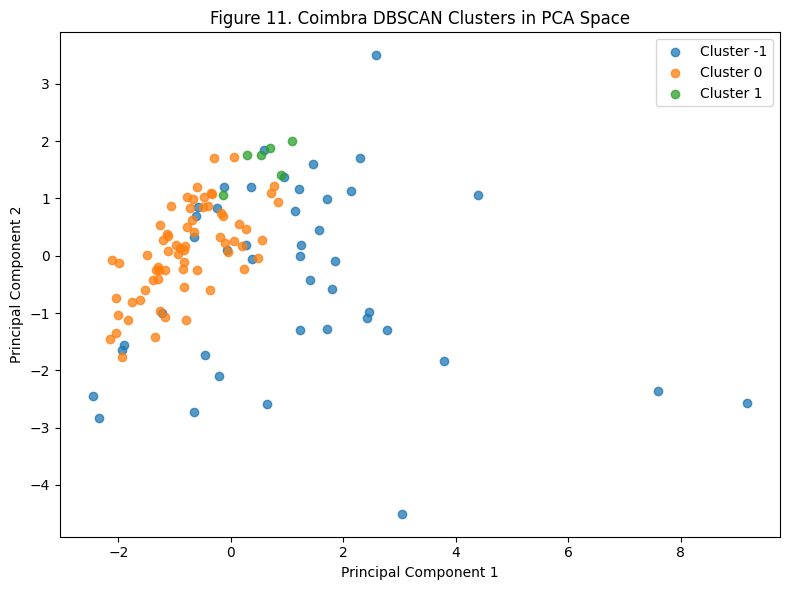

In [17]:
c_best_row = choose_dbscan(c_search)
c_best_eps = float(c_best_row["eps"])
c_best_min_samples = int(c_best_row["min_samples"])

c_dbscan = DBSCAN(eps=c_best_eps, min_samples=c_best_min_samples)
c_dbscan_labels = c_dbscan.fit_predict(X_c_scaled)
c_dbscan_summary = cluster_summary("Coimbra", f"DBSCAN eps={c_best_eps}, min_samples={c_best_min_samples}", c_dbscan_labels, y_c, X_c_scaled)

print("Selected Coimbra eps:", c_best_eps)
print("Selected Coimbra min_samples:", c_best_min_samples)
display(pd.DataFrame([c_dbscan_summary]))

display(pd.crosstab(pd.Series(c_dbscan_labels, name="DBSCAN_cluster"), coimbra_df["diagnosis_group"], margins=True))
plot_clusters(c_pca_df, c_dbscan_labels, "Figure 11. Coimbra DBSCAN Clusters in PCA Space")


### Coimbra DBSCAN interpretation

Coimbra may produce more noise or weaker density clusters because the dataset is smaller and the predictors are indirect biomarkers rather than direct tumor measurements.

## 16. Coimbra HAC linkage comparison

In [18]:
c_hac_df, c_hac_labels = hac_linkage_comparison(X_c_scaled, y_c, "Coimbra")
c_hac_df.sort_values("silhouette_all_points", ascending=False)


,dataset,method,clusters_excluding_noise,noise_points,noise_rate,silhouette_all_points,silhouette_without_noise,ARI_vs_known_label,NMI_vs_known_label,linkage
3,Coimbra,HAC linkage=single,2,0,0.0,0.610903,0.610903,-0.005865,0.026782,single
1,Coimbra,HAC linkage=complete,2,0,0.0,0.580695,0.580695,-0.007897,0.038767,complete
2,Coimbra,HAC linkage=average,2,0,0.0,0.580695,0.580695,-0.007897,0.038767,average
0,Coimbra,HAC linkage=ward,2,0,0.0,0.178114,0.178114,-0.005994,0.002723,ward


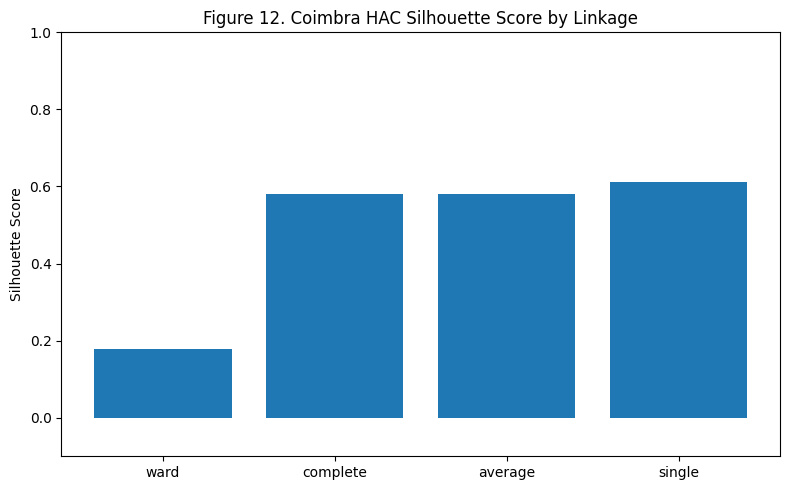

In [19]:
plt.figure(figsize=(8, 5))
plt.bar(c_hac_df["linkage"], c_hac_df["silhouette_all_points"])
plt.ylabel("Silhouette Score")
plt.title("Figure 12. Coimbra HAC Silhouette Score by Linkage")
plt.ylim(-0.1, 1.0)
plt.tight_layout()
plt.show()


## 17. Coimbra final HAC model

Best Coimbra linkage: single


,dataset,method,clusters_excluding_noise,noise_points,noise_rate,silhouette_all_points,silhouette_without_noise,ARI_vs_known_label,NMI_vs_known_label,linkage
3,Coimbra,HAC linkage=single,2,0,0.0,0.610903,0.610903,-0.005865,0.026782,single


diagnosis_group,Healthy Control,Patient,All
HAC_cluster,,,
0,52,62,114
1,0,2,2
All,52,64,116


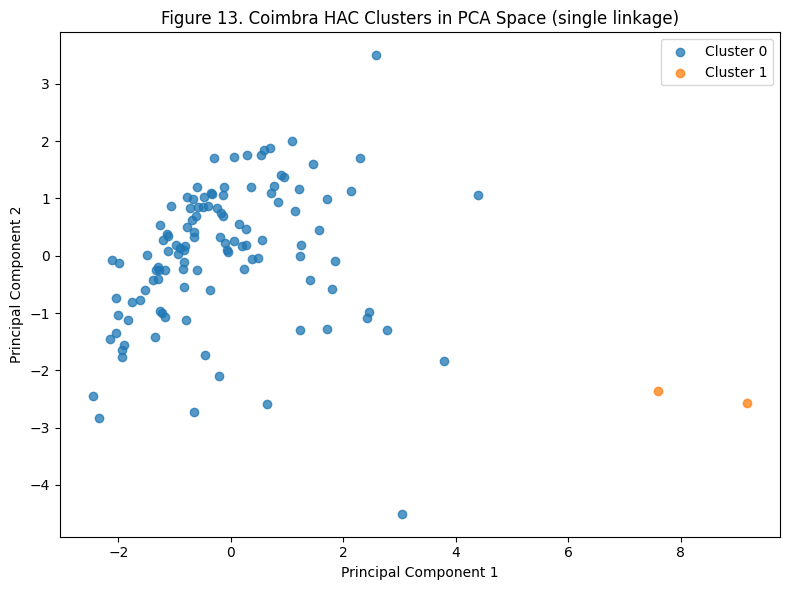

In [20]:
c_best_hac = c_hac_df.sort_values("silhouette_all_points", ascending=False).iloc[0]
c_best_linkage = c_best_hac["linkage"]
c_best_hac_labels = c_hac_labels[c_best_linkage]

print("Best Coimbra linkage:", c_best_linkage)
display(pd.DataFrame([c_best_hac]))
display(pd.crosstab(pd.Series(c_best_hac_labels, name="HAC_cluster"), coimbra_df["diagnosis_group"], margins=True))
plot_clusters(c_pca_df, c_best_hac_labels, f"Figure 13. Coimbra HAC Clusters in PCA Space ({c_best_linkage} linkage)")


## 18. Coimbra dendrograms

The Coimbra dataset is small enough that I can create dendrograms using the full dataset.

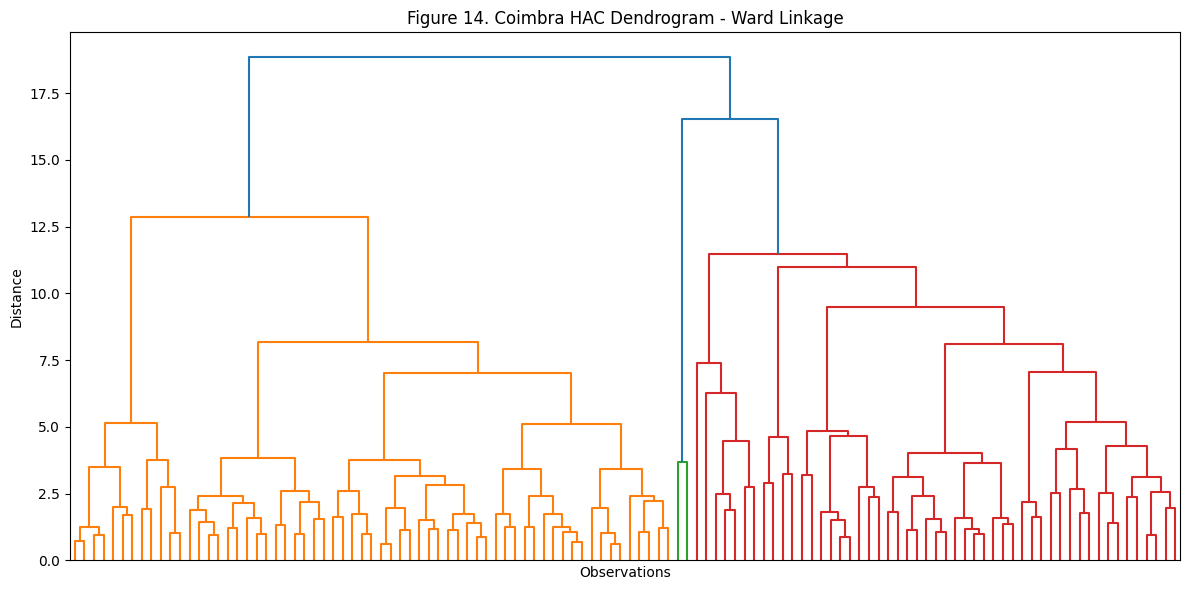

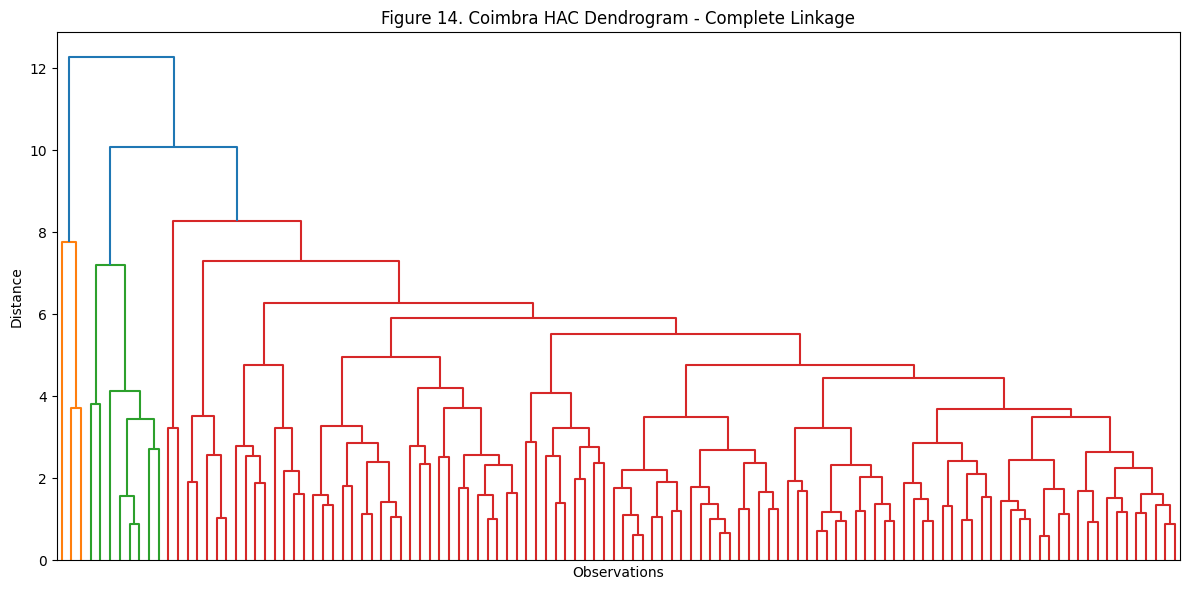

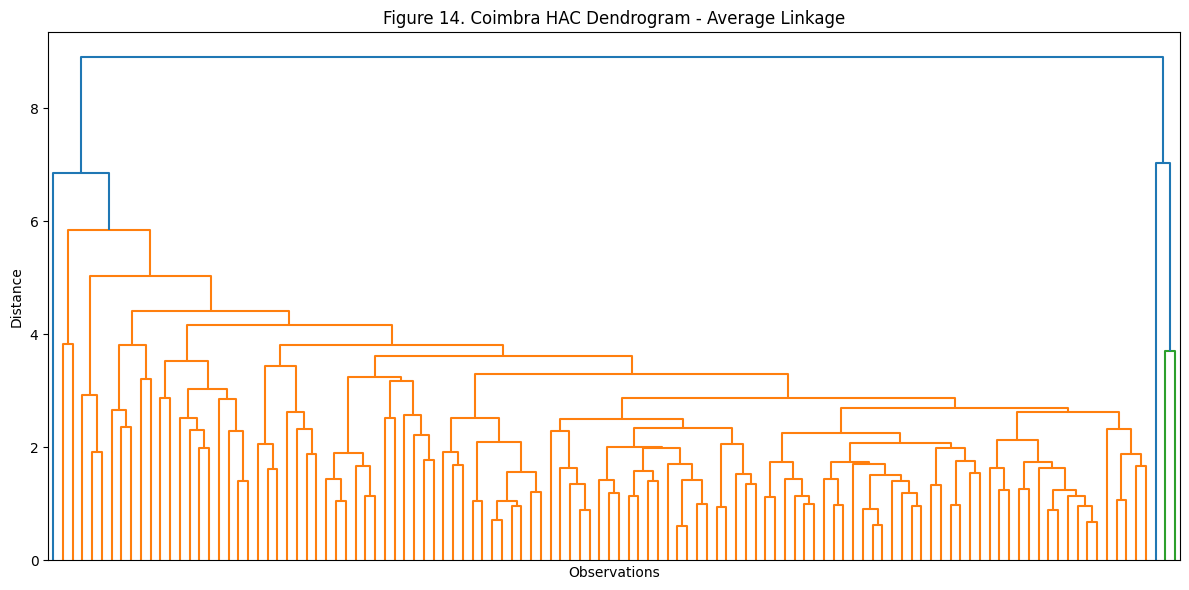

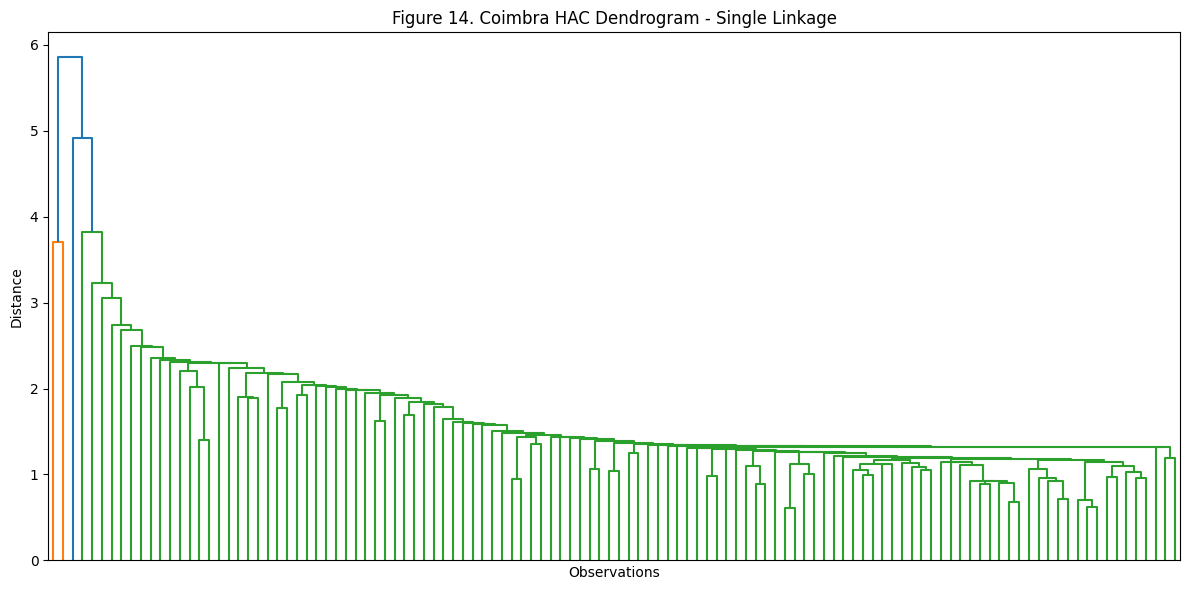

In [21]:
for method in ["ward", "complete", "average", "single"]:
    linked = linkage(X_c_scaled, method=method)
    plt.figure(figsize=(12, 6))
    dendrogram(linked, no_labels=True)
    plt.title(f"Figure 14. Coimbra HAC Dendrogram - {method.capitalize()} Linkage")
    plt.xlabel("Observations")
    plt.ylabel("Distance")
    plt.tight_layout()
    plt.show()


### Coimbra HAC interpretation

The dendrograms show how the patient profiles merge into larger clusters. If the dendrogram has large jumps in height, that may suggest more distinct groups. I expect Coimbra to show less clear separation than Wisconsin because its features are indirect clinical biomarkers.

# Part C — Dataset Comparison

## 19. Compare DBSCAN and HAC across Wisconsin and Coimbra

In [22]:
combined_summary = pd.DataFrame([
    w_dbscan_summary,
    dict(w_best_hac),
    c_dbscan_summary,
    dict(c_best_hac)
])

combined_summary


,dataset,method,clusters_excluding_noise,noise_points,noise_rate,silhouette_all_points,silhouette_without_noise,ARI_vs_known_label,NMI_vs_known_label,linkage
0,Wisconsin,"DBSCAN eps=3.0, min_samples=3",2,111,0.195079,0.256691,0.435961,0.120337,0.074060,NaN
1,Wisconsin,HAC linkage=complete,2,0,0.000000,0.660667,0.660667,0.004828,0.010182,complete
2,Coimbra,"DBSCAN eps=1.8, min_samples=8",2,43,0.370690,0.099921,0.273187,0.038505,0.059288,NaN
3,Coimbra,HAC linkage=single,2,0,0.000000,0.610903,0.610903,-0.005865,0.026782,single


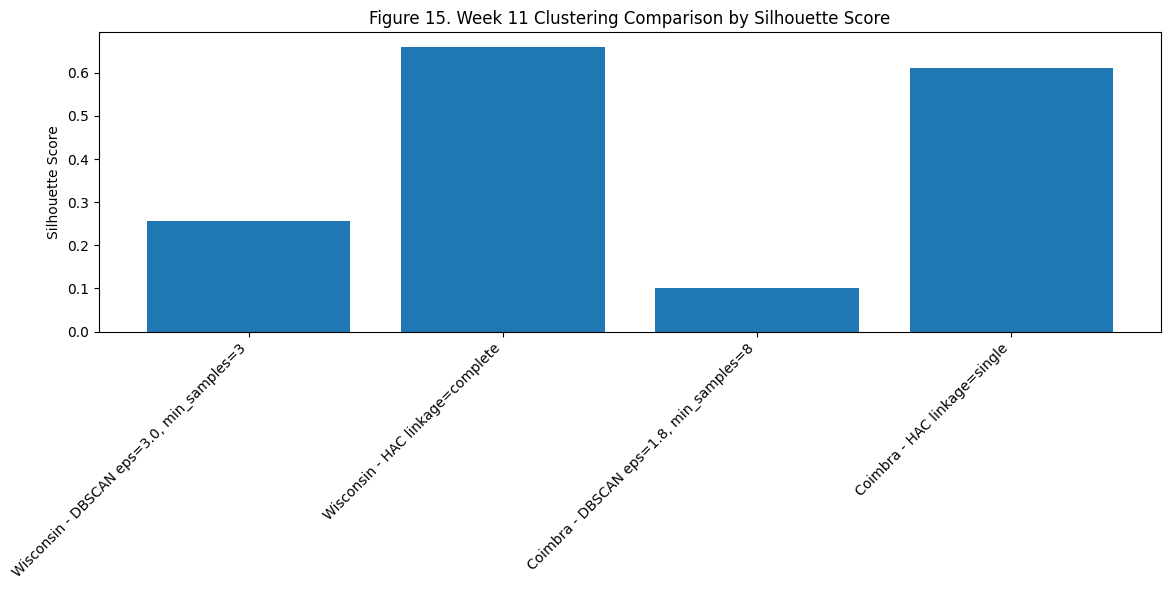

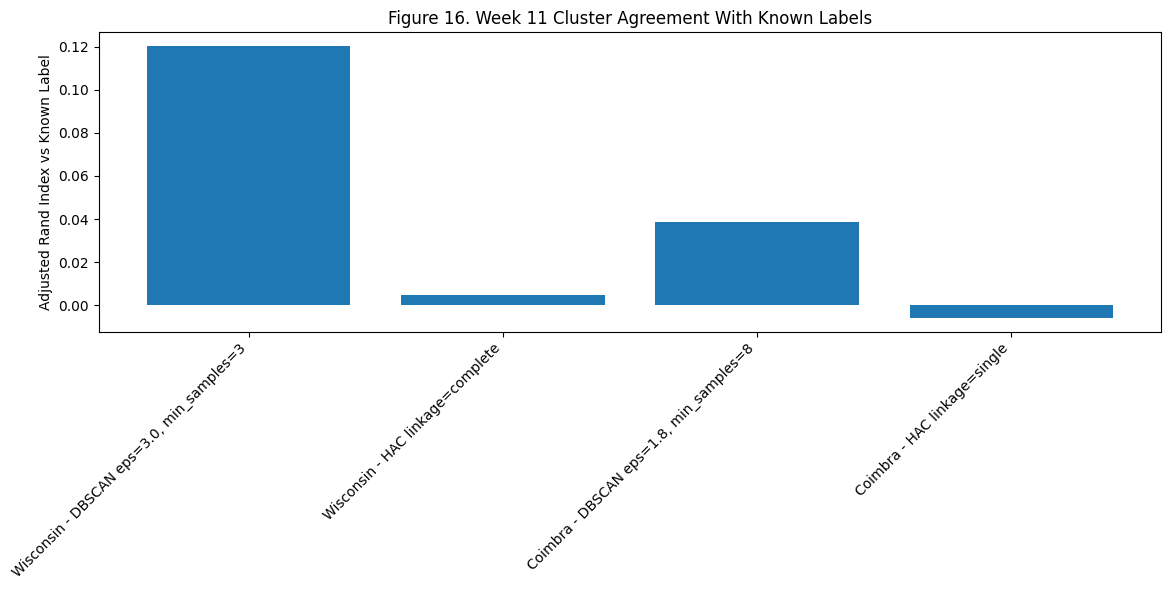

In [23]:
plot_df = combined_summary.copy()
plot_df["dataset_method"] = plot_df["dataset"] + " - " + plot_df["method"]

plt.figure(figsize=(12, 6))
plt.bar(plot_df["dataset_method"], plot_df["silhouette_all_points"])
plt.ylabel("Silhouette Score")
plt.title("Figure 15. Week 11 Clustering Comparison by Silhouette Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(plot_df["dataset_method"], plot_df["ARI_vs_known_label"])
plt.ylabel("Adjusted Rand Index vs Known Label")
plt.title("Figure 16. Week 11 Cluster Agreement With Known Labels")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 20. Week 11 summary

In [26]:
print("Week 11 Clustering Summary")

print("Wisconsin DBSCAN:")
print(f"eps: {w_best_eps}")
print(f"min_samples: {w_best_min_samples}")
print(f"clusters excluding noise: {w_dbscan_summary['clusters_excluding_noise']}")
print(f"noise rate: {w_dbscan_summary['noise_rate']:.4f}")
print(f"silhouette without noise: {w_dbscan_summary['silhouette_without_noise']:.4f}")

print("Wisconsin HAC:")
print(f"best linkage: {w_best_linkage}")
print(f"silhouette: {w_best_hac['silhouette_all_points']:.4f}")
print(f"ARI vs diagnosis: {w_best_hac['ARI_vs_known_label']:.4f}")

print("Coimbra DBSCAN:")
print(f"eps: {c_best_eps}")
print(f"min_samples: {c_best_min_samples}")
print(f"clusters excluding noise: {c_dbscan_summary['clusters_excluding_noise']}")
print(f"noise rate: {c_dbscan_summary['noise_rate']:.4f}")
print(f"silhouette without noise: {c_dbscan_summary['silhouette_without_noise']:.4f}")

print("Coimbra HAC:")
print(f"best linkage: {c_best_linkage}")
print(f"silhouette: {c_best_hac['silhouette_all_points']:.4f}")
print(f"ARI vs known group: {c_best_hac['ARI_vs_known_label']:.4f}")


Week 11 Clustering Summary
Wisconsin DBSCAN:
eps: 3.0
min_samples: 3
clusters excluding noise: 2
noise rate: 0.1951
silhouette without noise: 0.4360
Wisconsin HAC:
best linkage: complete
silhouette: 0.6607
ARI vs diagnosis: 0.0048
Coimbra DBSCAN:
eps: 1.8
min_samples: 8
clusters excluding noise: 2
noise rate: 0.3707
silhouette without noise: 0.2732
Coimbra HAC:
best linkage: single
silhouette: 0.6109
ARI vs known group: -0.0059


## 21. Week 11 findings and interpretation

This week helped me compare two clustering approaches that work differently from K-means.

**DBSCAN** looks for dense regions of points and labels unusual observations as noise. The `eps` value controls how close points need to be to count as neighbors, and `min_samples` controls how many nearby points are needed to form a dense region. If `eps` is too small, many observations become noise. If `eps` is too large, separate groups may merge together.

**Hierarchical agglomerative clustering** starts with each observation as its own cluster and merges observations step by step. The linkage method matters because each method defines cluster-to-cluster distance differently. Ward linkage tends to create compact clusters, complete linkage uses farthest distances, average linkage uses average distances, and single linkage uses nearest distances.

For the Wisconsin dataset, I expected stronger clustering because the tumor image measurements are directly related to benign versus malignant diagnosis. For Coimbra, I expected weaker clustering because the predictors are indirect clinical biomarkers and the dataset is smaller.

Overall, Week 11 showed that clustering can reveal structure in healthcare data, but it does not always match diagnosis labels perfectly. Clustering is exploratory. It can suggest subgroups and unusual observations, but it should not be interpreted the same way as supervised classification.

## 22. Wisconsin vs. Coimbra interpretation

The Wisconsin dataset is more naturally suited for clustering because its features describe physical tumor characteristics. These features are more likely to form groups related to malignancy.

The Coimbra dataset is still valuable, but blood-based biomarkers can vary for reasons beyond breast cancer status. This means the clusters may be less directly aligned with the known labels.

For Milestone Two, this notebook gives me evidence to discuss how unsupervised learning compares with supervised models. Supervised models directly optimize prediction of diagnosis, while DBSCAN and HAC only look for natural structure in the features.

## 23. References

UCI Machine Learning Repository. (n.d.). *Breast Cancer Wisconsin (Diagnostic) dataset*. https://doi.org/10.24432/C5DW2B

Patrício, M., Pereira, J., Crisóstomo, J., Matafome, P., Seiça, R., & Caramelo, F. (2018). *Breast Cancer Coimbra* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C52P59

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.

Scikit-learn developers. (n.d.). *DBSCAN*. https://scikit-learn.org/stable/modules/clustering.html#dbscan

Scikit-learn developers. (n.d.). *Hierarchical clustering*. https://scikit-learn.org/stable/modules/clustering.html#hierarchical-clustering

SciPy developers. (n.d.). *Hierarchical clustering*. https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html
